# Student Academic Performance — Data Visualization Practice

This Jupyter Notebook uses a **1,000-sample student dataset** for practical data visualization.

The examples are based on the uploaded *Types of Data Visualization* presentation, which covers basic charts, advanced charts, textual/symbolic charts, temporal/trend charts, choosing the right chart, and visualization best practices. fileciteturn0file0L35-L51

The basic chart examples include bar, line, pie, scatter and histogram. fileciteturn0file0L77-L98


In [1]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Load the 1,000-row CSV file.
df = pd.read_csv("student_academic_performance_1000.csv")

df.head()


,Student_ID,Age,Gender,Program,Year,Study_Hours_Per_Week,Attendance_Percent,Assignment_Score,Midterm_Score,Internet_Access,Previous_GPA,Extracurricular_Activities,Final_Score,Academic_Performance
0,STU0001,20,Female,Business Analytics,4,20.4,76.7,80.7,53.3,Yes,2.72,Multiple,100.0,High Distinction
1,STU0002,24,Male,Business Analytics,3,11.2,91.4,77.0,46.9,Yes,2.42,Sports,93.3,Distinction
2,STU0003,22,Male,Computer Science,3,16.5,86.0,59.1,69.6,Yes,2.08,NaN,100.0,Distinction
3,STU0004,21,Male,Information Technology,4,19.9,84.2,75.2,63.2,Yes,3.04,Sports,100.0,High Distinction
4,STU0005,19,Male,Information Technology,1,14.8,75.2,56.6,77.4,Yes,2.80,NaN,99.6,Distinction


In [2]:
# 2. Understand the dataset
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

df.describe()


Rows: 1000
Columns: 14

Column names:
['Student_ID', 'Age', 'Gender', 'Program', 'Year', 'Study_Hours_Per_Week', 'Attendance_Percent', 'Assignment_Score', 'Midterm_Score', 'Internet_Access', 'Previous_GPA', 'Extracurricular_Activities', 'Final_Score', 'Academic_Performance']

Missing values:
Student_ID                      0
Age                             0
Gender                          0
Program                         0
Year                            0
Study_Hours_Per_Week            8
Attendance_Percent              8
Assignment_Score                8
Midterm_Score                   0
Internet_Access                 0
Previous_GPA                    8
Extracurricular_Activities    289
Final_Score                     0
Academic_Performance            0
dtype: int64


,Age,Year,Study_Hours_Per_Week,Attendance_Percent,Assignment_Score,Midterm_Score,Previous_GPA,Final_Score
count,1000.000000,1000.000000,992.000000,992.000000,992.000000,1000.000000,992.000000,1000.000000
mean,20.710000,2.374000,15.134577,83.345766,71.511794,67.273400,3.057218,96.143800
std,1.710797,1.090556,6.463711,8.633233,12.602143,15.232864,0.456484,6.698383
min,18.000000,1.000000,2.000000,55.500000,30.700000,24.500000,1.500000,62.500000
25%,19.000000,1.000000,10.700000,77.600000,63.400000,56.600000,2.750000,93.900000
50%,21.000000,2.000000,14.800000,83.700000,71.500000,67.150000,3.050000,100.000000
75%,22.000000,3.000000,19.200000,89.300000,80.300000,78.200000,3.380000,100.000000
max,25.000000,4.000000,50.000000,100.000000,100.000000,100.000000,4.000000,100.000000


## 3. Bar Chart — Category Comparison

Use a bar chart to compare categories or rank groups. The presentation identifies bar charts as suitable for ranking and category comparison. fileciteturn0file0L80-L82


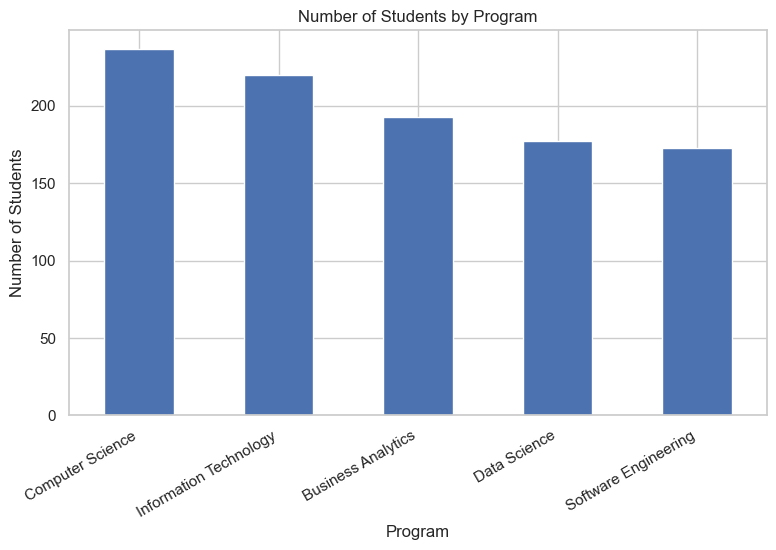

In [ ]:
# Example: number of students in each program
counts = df["Program"].value_counts()

plt.figure(figsize=(9,5))
counts.plot(kind="bar")
plt.title("Number of Students by Program")
plt.xlabel("Program")
plt.ylabel("Number of Students")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4. Line Chart — Trend

Use a line chart to show how a value changes across an ordered sequence or time. fileciteturn0file0L84-L86


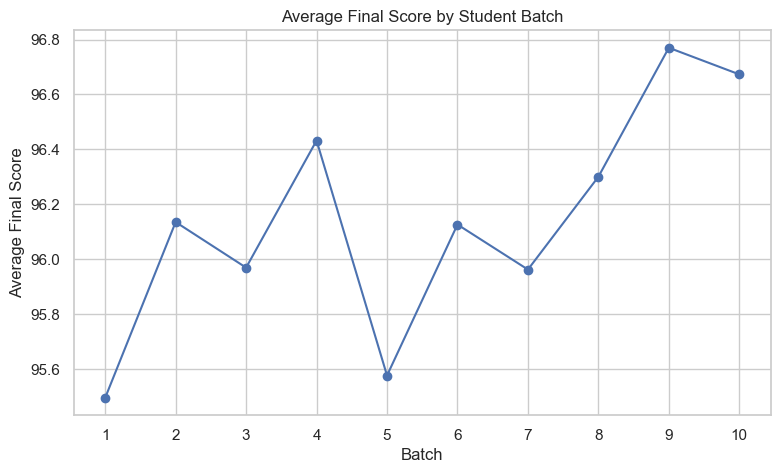

In [7]:
# The dataset has no real calendar date, so we create 10 teaching batches.
df["Batch"] = df.index // 100 + 1
batch_score = df.groupby("Batch")["Final_Score"].mean()

plt.figure(figsize=(9,5))
plt.plot(batch_score.index, batch_score.values, marker="o")
plt.title("Average Final Score by Student Batch")
plt.xlabel("Batch")
plt.ylabel("Average Final Score")
plt.xticks(batch_score.index)
plt.show()


## 5. Pie Chart — Part-to-Whole

A pie chart shows how a small number of categories contribute to a whole. fileciteturn0file0L88-L90


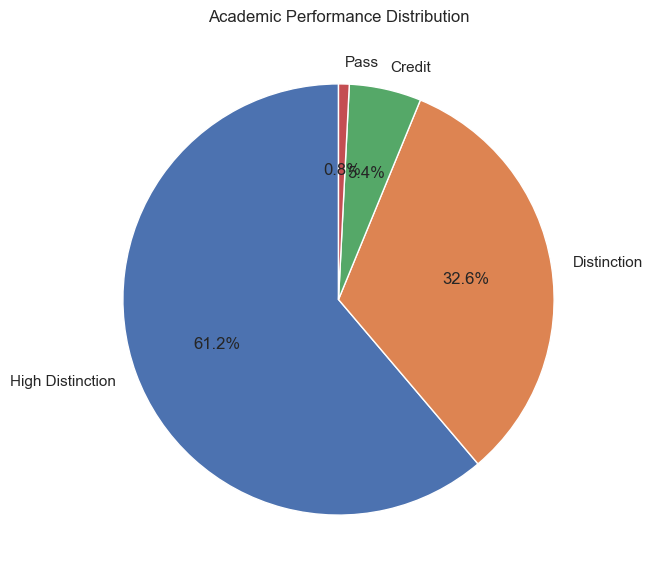

In [11]:
# Example: academic performance proportions
x = df["Academic_Performance"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(x.values, labels=x.index, autopct="%1.1f%%", startangle=90)
plt.title("Academic Performance Distribution")
plt.show()


## 6. Scatter Plot — Relationship

Use a scatter plot to investigate the relationship between two numeric variables and identify clusters or outliers. fileciteturn0file0L92-L94


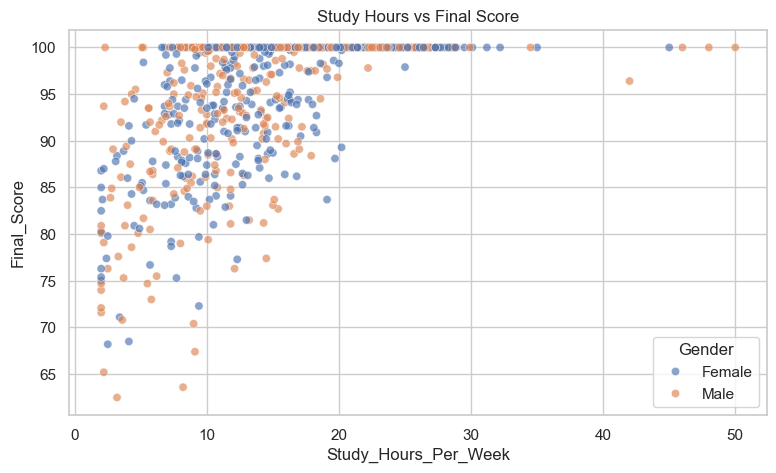

In [12]:
# Example: study hours versus final score
x = df.dropna(subset=["Study_Hours_Per_Week","Final_Score"])

plt.figure(figsize=(9,5))
sns.scatterplot(data=x, x="Study_Hours_Per_Week", y="Final_Score", hue="Gender", alpha=.65)
plt.title("Study Hours vs Final Score")
plt.show()


## 7. Histogram — Distribution

A histogram groups numeric values into bins and shows their frequency. fileciteturn0file0L96-L98


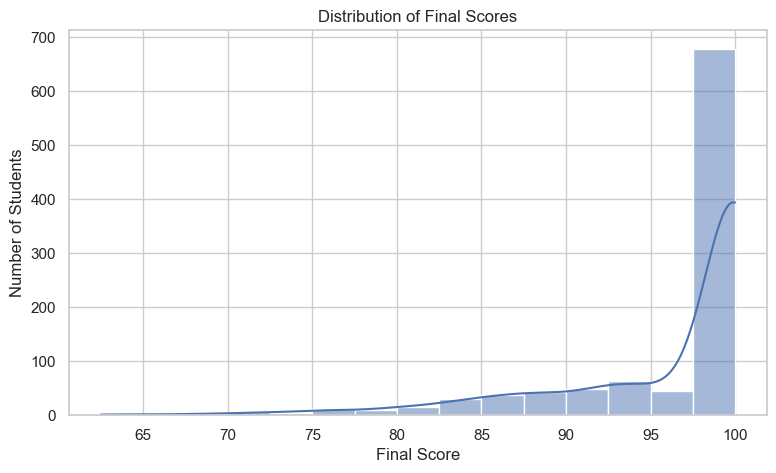

In [13]:
# Example: distribution of final scores
plt.figure(figsize=(9,5))
sns.histplot(df["Final_Score"], bins=15, kde=True)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Number of Students")
plt.show()


## 8. Heatmap — Correlation

The presentation describes a heatmap as a color-coded matrix useful for seeing correlation and variation. fileciteturn0file0L151-L153


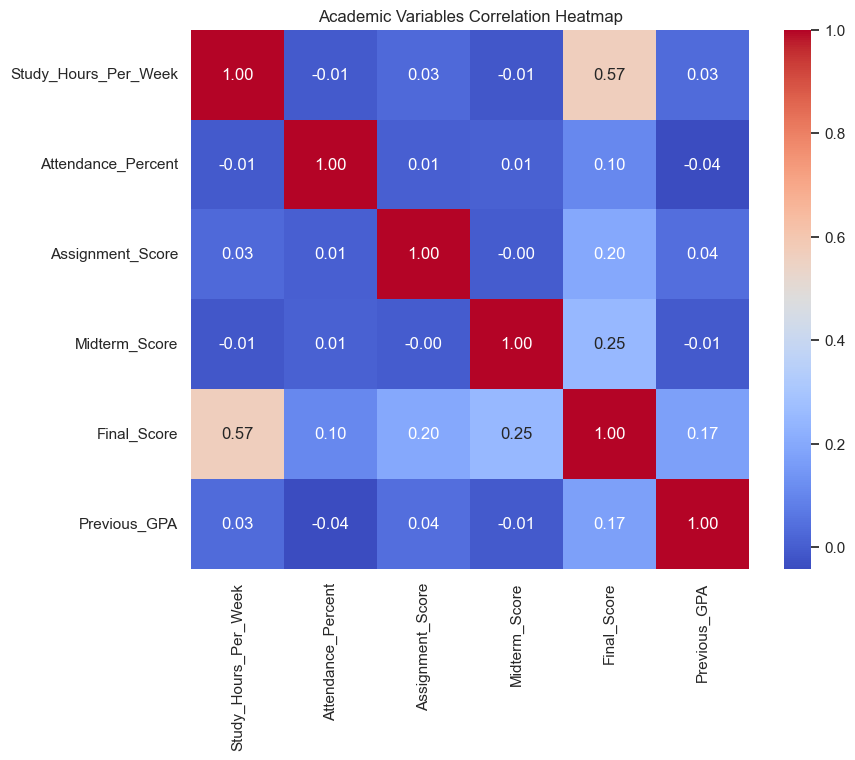

In [14]:
# Example: correlation between academic variables
cols = [
    "Study_Hours_Per_Week","Attendance_Percent",
    "Assignment_Score","Midterm_Score","Final_Score","Previous_GPA"
]
corr = df[cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Academic Variables Correlation Heatmap")
plt.show()


## 9. Area Chart — Magnitude Across a Sequence

An area chart emphasizes magnitude across an ordered sequence. fileciteturn0file0L155-L156


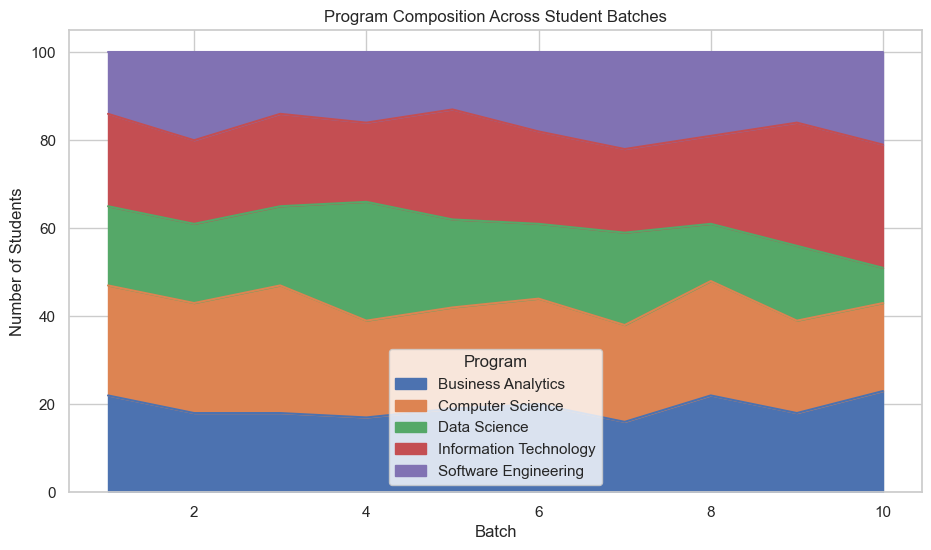

In [15]:
# Example: program composition across batches
area_data = pd.crosstab(df["Batch"], df["Program"])

area_data.plot.area(figsize=(11,6))
plt.title("Program Composition Across Student Batches")
plt.xlabel("Batch")
plt.ylabel("Number of Students")
plt.show()


## 10. Box Plot — Spread and Outliers

A box plot summarizes median, quartiles and possible outliers. fileciteturn0file0L159-L160


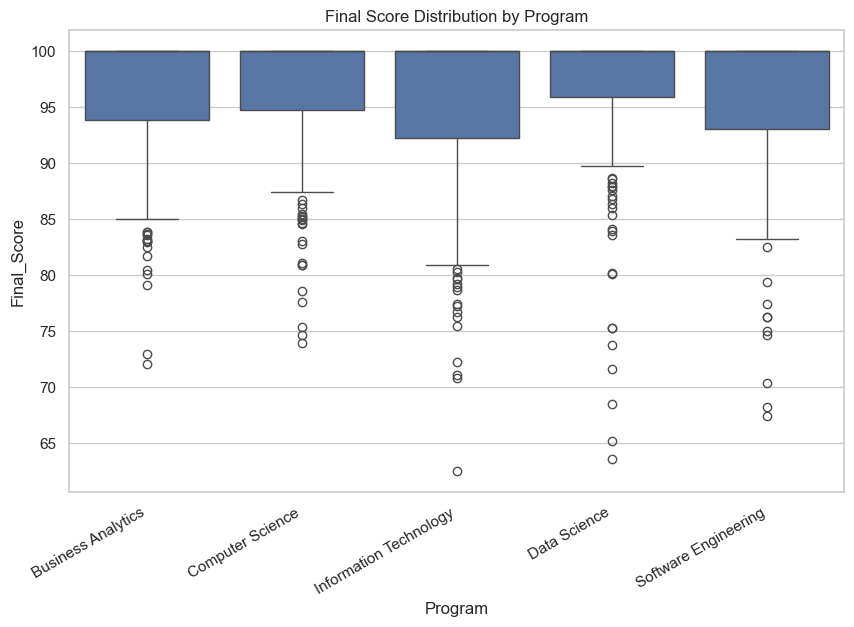

In [16]:
# Example: final-score spread by program
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Program", y="Final_Score")
plt.title("Final Score Distribution by Program")
plt.xticks(rotation=30, ha="right")
plt.show()


## 11. Bubble Chart — Three Variables

A bubble chart adds another variable through marker size. fileciteturn0file0L163-L165


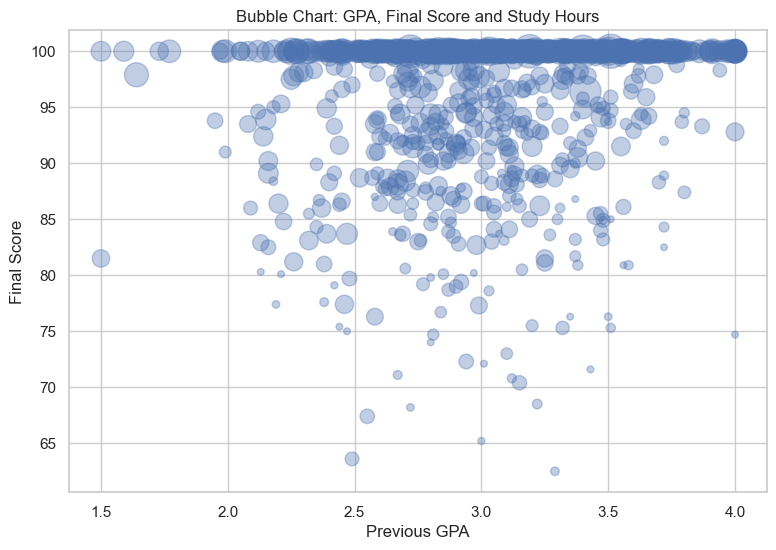

In [17]:
# X = GPA, Y = Final Score, bubble size = study hours
x = df.dropna(subset=["Previous_GPA","Final_Score","Study_Hours_Per_Week"])

plt.figure(figsize=(9,6))
plt.scatter(
    x["Previous_GPA"], x["Final_Score"],
    s=x["Study_Hours_Per_Week"]*12, alpha=.35
)
plt.xlabel("Previous GPA")
plt.ylabel("Final Score")
plt.title("Bubble Chart: GPA, Final Score and Study Hours")
plt.show()


## 13. Parallel Coordinates — Many Variables

Parallel coordinates display multiple variables for each record using connected lines. fileciteturn0file0L199-L200


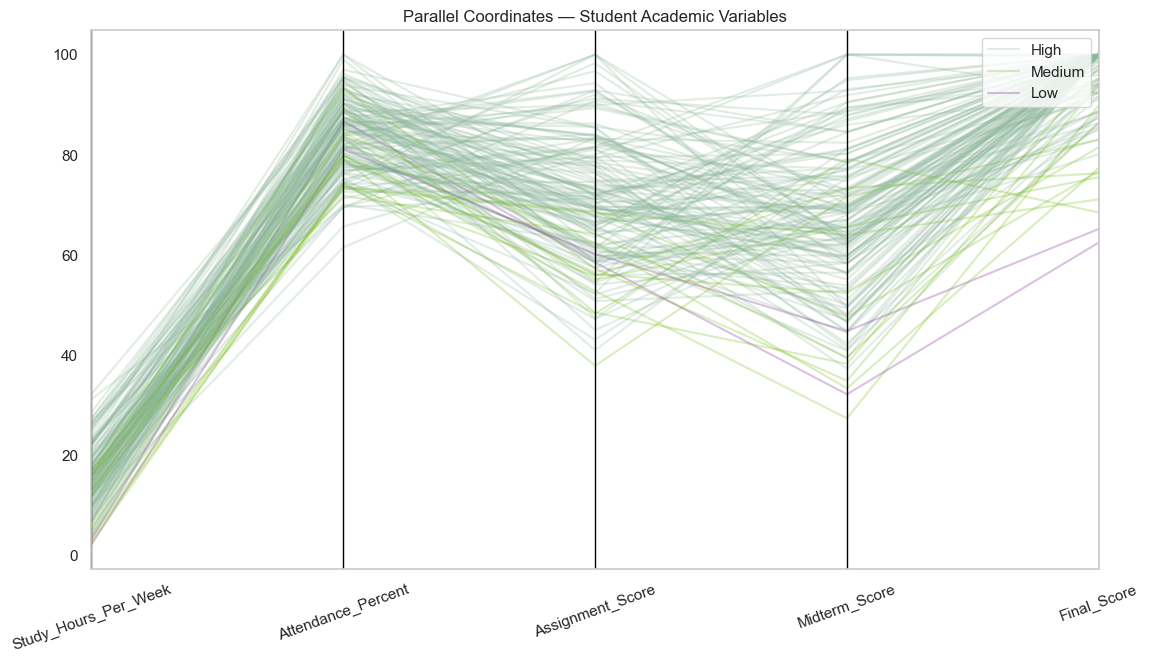

In [18]:
from pandas.plotting import parallel_coordinates

cols = [
    "Study_Hours_Per_Week","Attendance_Percent",
    "Assignment_Score","Midterm_Score","Final_Score"
]

p = df.dropna(subset=cols).copy()
p["Performance_Group"] = p["Academic_Performance"].replace({
    "High Distinction":"High",
    "Distinction":"High",
    "Credit":"Medium",
    "Pass":"Low",
    "Fail":"Low"
})

p = p.sample(min(150,len(p)), random_state=42)

plt.figure(figsize=(13,7))
parallel_coordinates(p[["Performance_Group"]+cols], "Performance_Group", alpha=.25)
plt.title("Parallel Coordinates — Student Academic Variables")
plt.xticks(rotation=20)
plt.show()


## 14. Violin Plot — Distribution Shape

A violin plot combines spread information with a density shape and is useful for comparing distributions across groups. fileciteturn0file0L237-L239


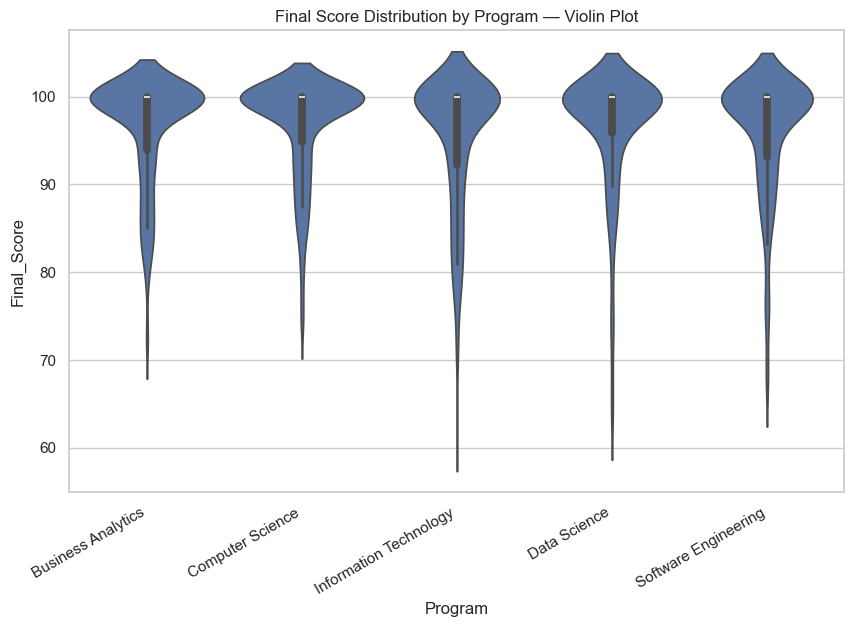

In [19]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="Program", y="Final_Score")
plt.title("Final Score Distribution by Program — Violin Plot")
plt.xticks(rotation=30, ha="right")
plt.show()


## 15. Hexbin Plot — Dense Data

A hexbin plot groups points into hexagonal bins and is useful for dense relationships where an ordinary scatter plot can become crowded. fileciteturn0file0L233-L235


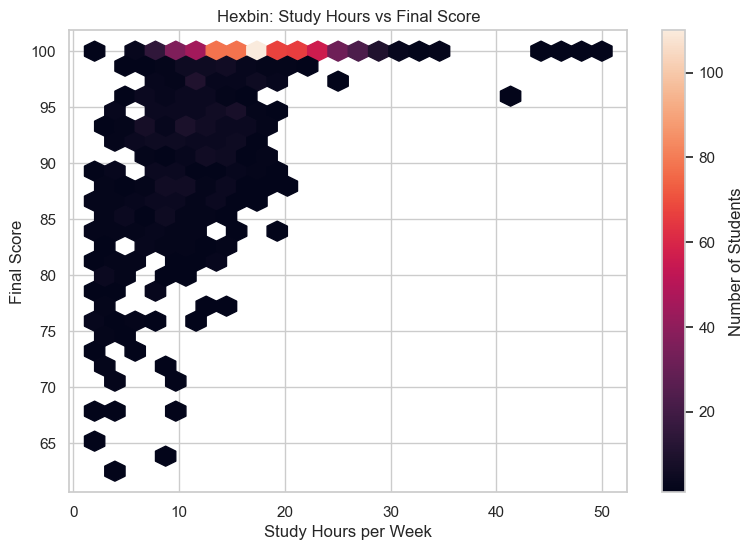

In [20]:
x = df.dropna(subset=["Study_Hours_Per_Week","Final_Score"])

plt.figure(figsize=(9,6))
plt.hexbin(x["Study_Hours_Per_Week"], x["Final_Score"], gridsize=25, mincnt=1)
plt.colorbar(label="Number of Students")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")
plt.title("Hexbin: Study Hours vs Final Score")
plt.show()


## 16. Radar Chart — Multi-Criteria Comparison

Radar charts can compare multiple criteria. The presentation uses this form for multi-criteria comparison. fileciteturn0file0L221-L247


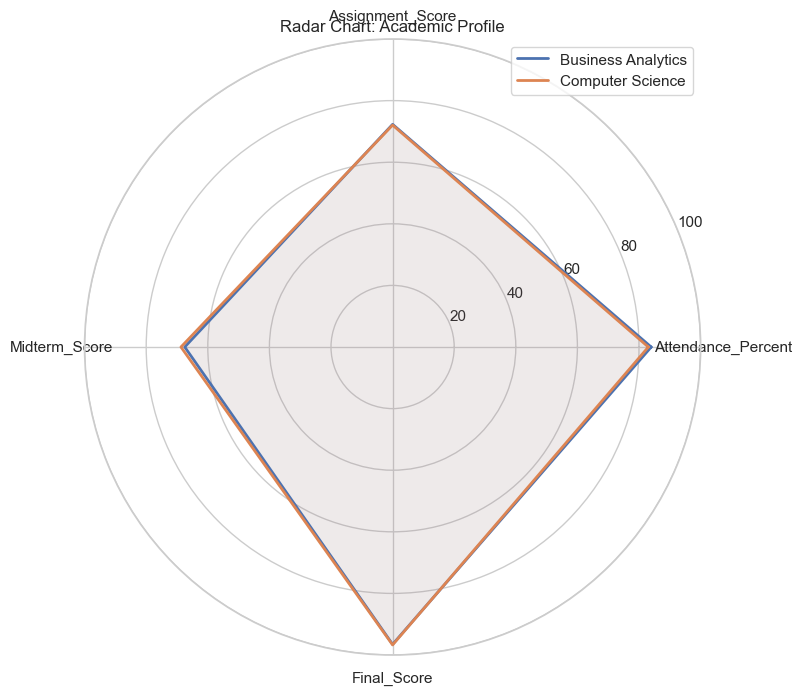

In [21]:
from math import pi

# Select two programs for a simple classroom comparison.
programs = df["Program"].dropna().unique()[:2]
metrics = ["Attendance_Percent","Assignment_Score","Midterm_Score","Final_Score"]

r = df[df["Program"].isin(programs)].groupby("Program")[metrics].mean()
angles = np.linspace(0, 2*pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, polar=True)

for program in programs:
    values = r.loc[program].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=program)
    ax.fill(angles, values, alpha=.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0,100)
ax.set_title("Radar Chart: Academic Profile")
ax.legend()
plt.show()


## 17. Word Cloud — Textual Data

The presentation includes word clouds under textual and symbolic visualization. Word size represents frequency. fileciteturn0file0L251-L255

The student CSV does not contain open-ended comments, so this example uses a small practice feedback text.


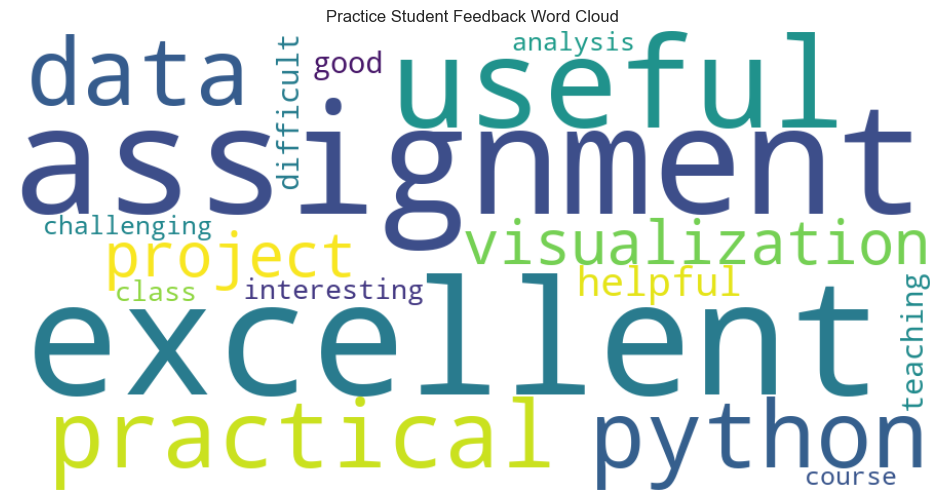

In [23]:
# Optional package: run this cell once if necessary
!pip install wordcloud

from wordcloud import WordCloud

comments = """
good excellent teaching assignment difficult useful practical
python data visualization interesting class project helpful
assignment useful python practical project challenging
excellent course data analysis helpful visualization
"""

wc = WordCloud(width=900, height=450, background_color="white").generate(comments)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Practice Student Feedback Word Cloud")
plt.show()


## 18. Pictogram — Symbolic Visualization

A pictogram uses repeated icons/symbols to represent quantities. fileciteturn0file0L255-L259


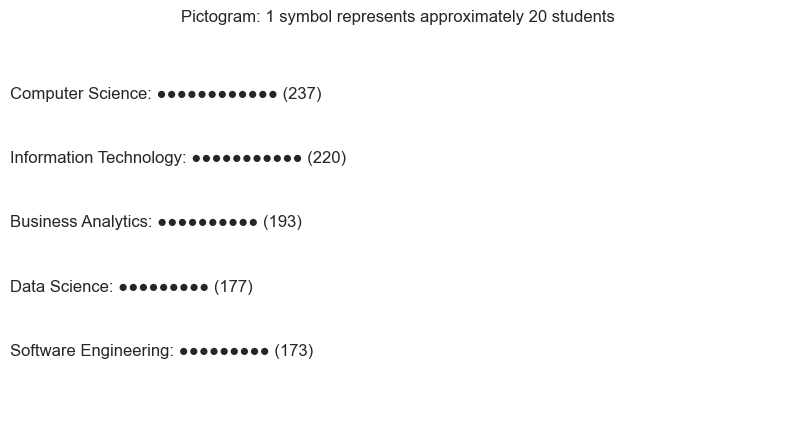

In [24]:
counts = df["Program"].value_counts().sort_values()

plt.figure(figsize=(10,5))
for i,(program,count) in enumerate(counts.items()):
    symbols = "●" * max(1, round(count/20))
    plt.text(0, i, f"{program}: {symbols} ({count})", fontsize=12, va="center")

plt.xlim(0,70)
plt.ylim(-1,len(counts))
plt.axis("off")
plt.title("Pictogram: 1 symbol represents approximately 20 students")
plt.show()


## 19. Streamgraph-Style Chart

The presentation describes streamgraphs as flowing stacked areas for showing how categories ebb and flow over time. fileciteturn0file0L269-L274

Here we create a classroom approximation using a stacked area chart.


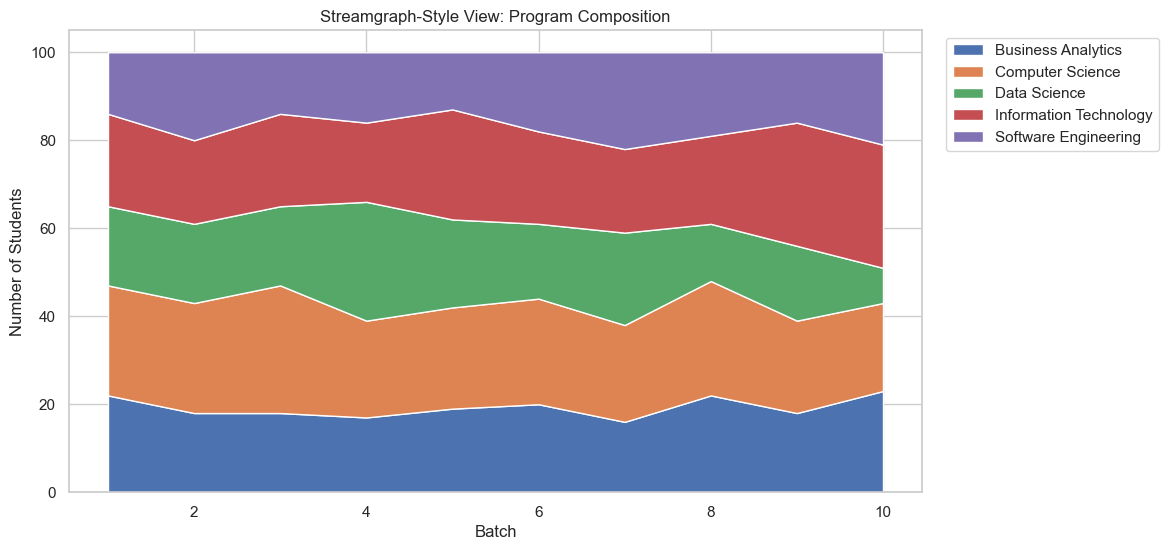

In [25]:
stream = pd.crosstab(df["Batch"], df["Program"])

plt.figure(figsize=(11,6))
plt.stackplot(
    stream.index,
    *[stream[c].values for c in stream.columns],
    labels=stream.columns
)
plt.title("Streamgraph-Style View: Program Composition")
plt.xlabel("Batch")
plt.ylabel("Number of Students")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.show()


## 20. Bullet Graph — Actual vs Target

A bullet graph is useful for comparing one KPI against a target. fileciteturn0file0L276-L277


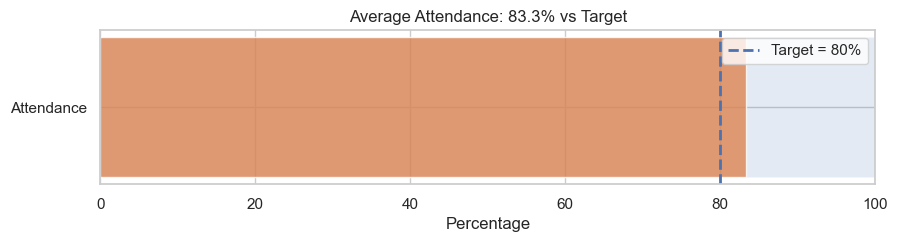

In [26]:
actual = df["Attendance_Percent"].mean()
target = 80

plt.figure(figsize=(10,2))
plt.barh(["Attendance"], [100], alpha=.15)
plt.barh(["Attendance"], [actual], alpha=.8)
plt.axvline(target, linestyle="--", linewidth=2, label=f"Target = {target}%")
plt.xlim(0,100)
plt.xlabel("Percentage")
plt.title(f"Average Attendance: {actual:.1f}% vs Target")
plt.legend()
plt.show()


## 21. Gantt Chart — Project Schedule

A Gantt chart shows tasks, duration and scheduling across a timeline. fileciteturn0file0L280-L281


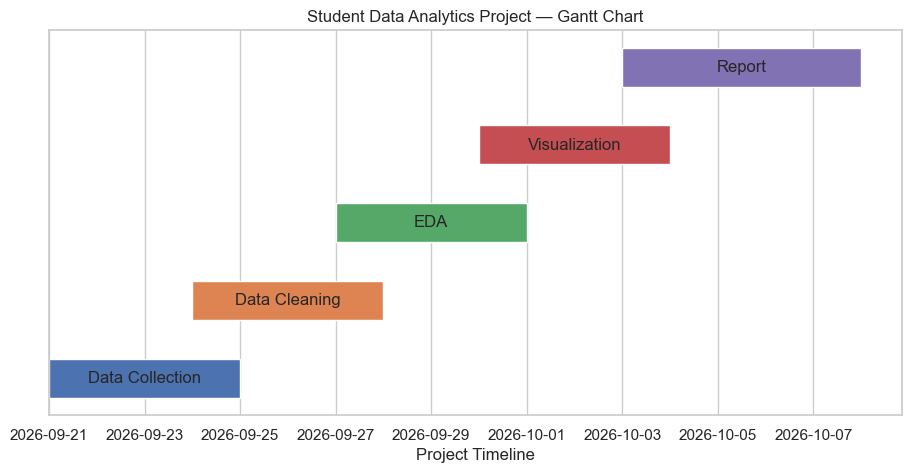

In [27]:
from datetime import datetime, timedelta

tasks = [
    ("Data Collection",0,4),
    ("Data Cleaning",3,4),
    ("EDA",6,4),
    ("Visualization",9,4),
    ("Report",12,5)
]

start_date = datetime(2026,9,21)

plt.figure(figsize=(11,5))
for i,(task,start_day,duration) in enumerate(tasks):
    start = start_date + timedelta(days=start_day)
    plt.barh(i, duration, left=start, height=.5)
    plt.text(start + timedelta(days=duration/2), i, task,
             ha="center", va="center")

plt.yticks([])
plt.xlabel("Project Timeline")
plt.title("Student Data Analytics Project — Gantt Chart")
plt.show()


## 22. Waterfall Chart — Sequential Changes

A waterfall chart shows how positive and negative changes build toward a final total. fileciteturn0file0L284-L285


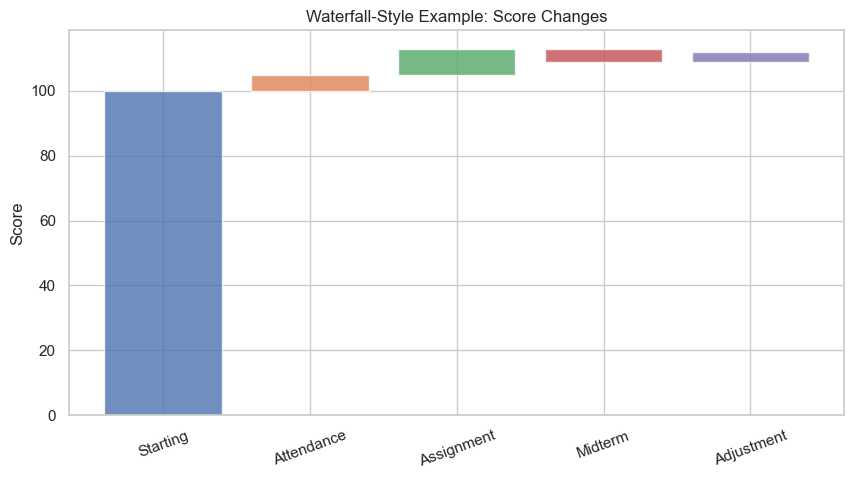

Final value: 112


In [28]:
steps = ["Starting","Attendance","Assignment","Midterm","Adjustment"]
changes = [100,5,8,-4,3]

levels = [changes[0]]
for change in changes[1:]:
    levels.append(levels[-1] + change)

plt.figure(figsize=(10,5))
for i,change in enumerate(changes):
    if i == 0:
        bottom, height = 0, change
    else:
        bottom = min(levels[i-1], levels[i])
        height = abs(change)
    plt.bar(i, height, bottom=bottom, alpha=.8)

plt.xticks(range(len(steps)), steps, rotation=20)
plt.ylabel("Score")
plt.title("Waterfall-Style Example: Score Changes")
plt.show()

print("Final value:", levels[-1])


# Student Practice Tasks

The presentation recommends choosing a visualization based on the question: compare categories, show composition, track change, reveal distribution, explore relationships, or map flows/networks. fileciteturn0file0L294-L308

### Beginner
1. Bar chart: number of students by **Gender**.
2. Histogram: **Attendance_Percent**.
3. Pie chart: **Internet_Access**.
4. Box plot: **Final_Score by Gender**.
5. Scatter plot: **Midterm_Score vs Final_Score**.

### Intermediate
6. Bar chart: average **Final_Score by Program**.
7. Heatmap: all numeric academic variables.
8. Box plot: **Study_Hours_Per_Week by Academic_Performance**.
9. Bubble chart: X = Attendance, Y = Final Score, size = Previous GPA.
10. Find the top 3 programs by average final score and visualize them.

### Data Cleaning
11. Find missing values.
12. Calculate missing-value percentages.
13. Replace missing numeric values with the median.
14. Identify outliers in Study_Hours_Per_Week.
15. Explain whether each outlier should be removed, capped, or investigated.

### Interpretation
16. Does attendance appear related to final score?
17. Which program has the highest average final score?
18. Which program has the greatest score variation?
19. Compare academic performance for students with and without internet access.
20. Compare students with different extracurricular activities.

### Challenge
21. Build a mini-dashboard with at least **4 different charts**.
22. Give the dashboard a meaningful title.
23. Include at least two filters or selections.
24. Write three findings.
25. For every chart, explain **what question it answers, why you selected the chart, what it shows, and what action/decision it could support**.

### Final Mini Project
Choose one research question about student academic performance. Submit:
- Research question
- Data cleaning
- At least 5 visualizations
- Explanation of every visualization
- At least 3 findings
- Conclusion
- Explanation of why your selected chart types were appropriate

The goal is not only to draw charts, but to **interpret the data and communicate meaningful findings**.
